## Pulsar Yıldızı Sınıflandırması: Support Vector Classifier (SVC) Yaklaşımı
--- 

Bu proje, uzaydan gelen radyo frekans sinyallerini analiz ederek bir gök cisminin Pulsar yıldızı olup olmadığını tahmin etmeyi amaçlamaktadır. Sınıflandırma görevinde, dengesiz veri setleriyle iyi başa çıkabilen Support Vector Classifier (SVC) modeli kullanılmış ve modelin performansı GridSearchCV ile hiperparametre optimizasyonu yapılarak artırılmıştır.

### 1. Gerekli Kütüphanelerin İçeri Aktarılması

> Veri manipülasyonu, görselleştirme ve makine öğrenmesi modelleme işlemleri için kullanacağımız standart kütüphaneleri projemize dahil ediyoruz.

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme ayarları
%matplotlib inline
sns.set_theme(style="whitegrid")

# Scikit-learn modülleri
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### 2. Veri Yükleme ve Ön İnceleme
> Veri setini yüklüyor ve sütun isimlerindeki olası boşluk hatalarını (whitespace) temizleyerek işe başlıyoruz.

In [3]:
df = pd.read_csv("pulsar_stars.csv")

In [4]:
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Mean of the integrated profile                17898 non-null  float64
 1   Standard deviation of the integrated profile  17898 non-null  float64
 2   Excess kurtosis of the integrated profile     17898 non-null  float64
 3   Skewness of the integrated profile            17898 non-null  float64
 4   Mean of the DM-SNR curve                      17898 non-null  float64
 5   Standard deviation of the DM-SNR curve        17898 non-null  float64
 6   Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7   Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                  17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [5]:
df.columns

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='str')

In [6]:
df.columns = df.columns.str.lstrip()

In [21]:
df["target_class"].value_counts()

target_class
0    16259
1     1639
Name: count, dtype: int64

### 3. Keşifçi Veri Analizi (EDA) ve Görselleştirme
> Veriyi modele vermeden önce, hedef değişkenimizin (target_class) dağılımını ve özellikler (features) arasındaki ilişkileri anlamak için görselleştiriyoruz.

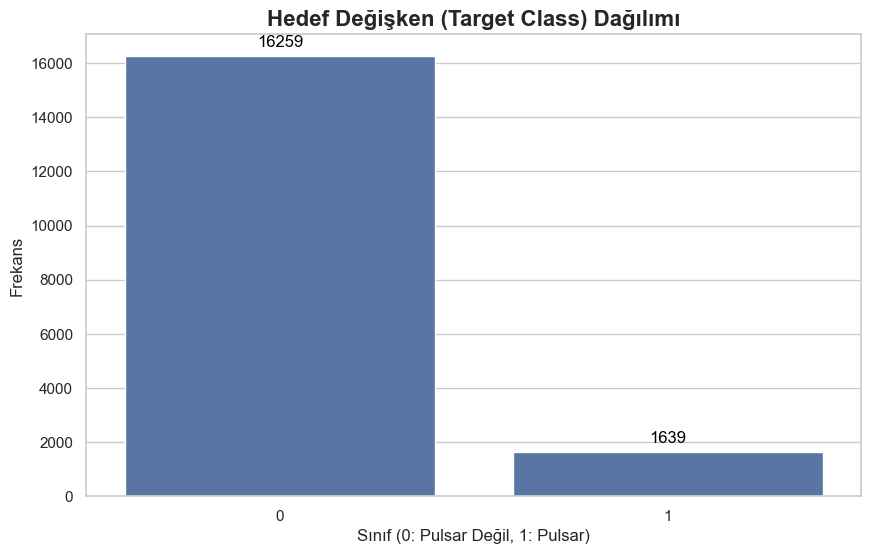

In [12]:
# --- 1. Sınıf Dağılımı (Hedef Değişken) ---
plt.figure(figsize=(10, 6)) 
ax = sns.countplot(data=df, x="target_class") 
plt.title("Hedef Değişken (Target Class) Dağılımı", fontsize=16, fontweight='bold')
plt.xlabel("Sınıf (0: Pulsar Değil, 1: Pulsar)", fontsize=12)
plt.ylabel("Frekans", fontsize=12)

# Çubukların üzerine sayıları ekleme - daha profesyonel konumlandırma
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),
                textcoords='offset points')

plt.show()

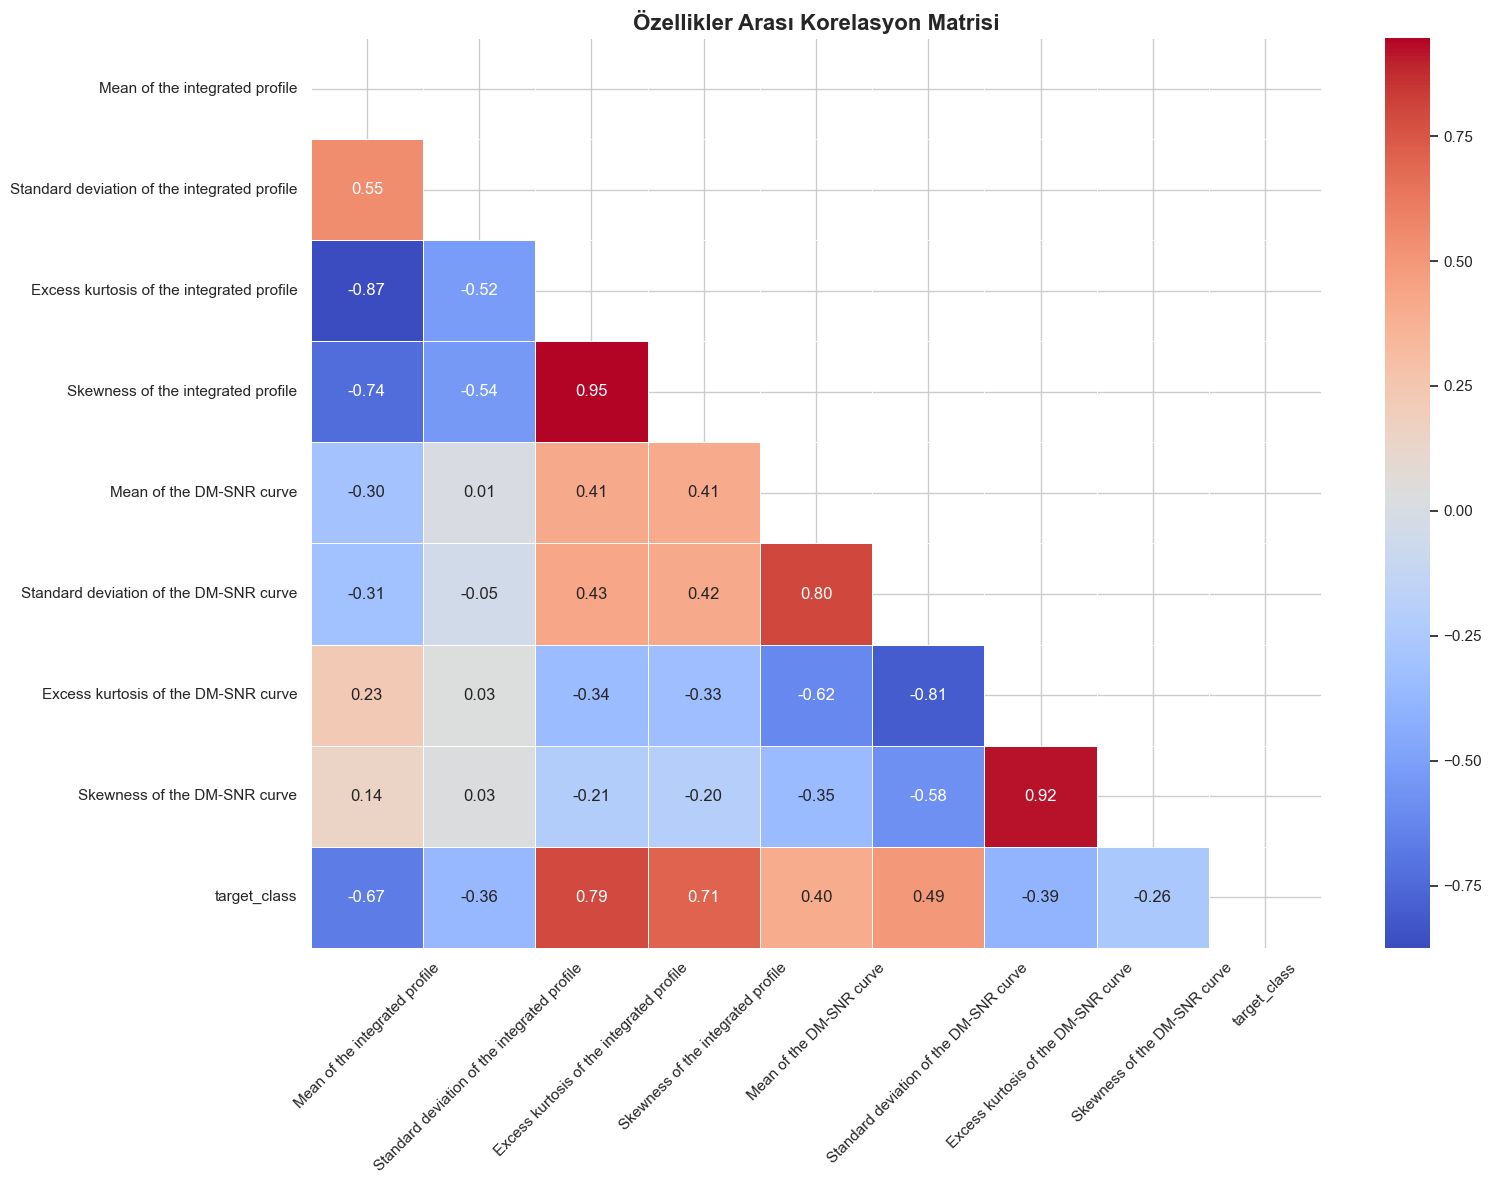

In [18]:
# --- 2. Korelasyon Matrisi ---
plt.figure(figsize=(16, 12)) 
corr = df.corr()

mask = np.triu(np.ones_like(df.corr(numeric_only=True),dtype=bool))

# Değerleri göster (annot=True), daha okunaklı renk paleti kullan, formatı ayarla
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, cbar=True ,mask=mask )
plt.title("Özellikler Arası Korelasyon Matrisi", fontsize=16, fontweight='bold')
plt.xticks(rotation=45) # Eksen etiketlerini döndür
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 4. Veri Ön İşleme (Preprocessing)

> Modelin eğitimi için bağımlı ve bağımsız değişkenleri ayırıyor, ardından veri setini eğitim ve test olarak bölüyoruz. SVC modeli özelliklerin ölçeğine duyarlı olduğu için (mesafe tabanlı bir algoritma olduğundan) StandardScaler ile veriyi standartlaştırıyoruz.

In [23]:
X = df.drop("target_class" ,axis=1)
y = df["target_class"]

In [24]:
# Stratify=y parametresi, sınıfların eğitim ve test setine orantılı dağılmasını sağlar.
X_train , X_test , y_train , y_test = train_test_split(X , y , train_size= 0.2 , random_state=42 ,stratify=y)

In [25]:
scaler = StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. Model Kurulumu ve Hiperparametre Optimizasyonu
> En iyi performansı elde etmek için GridSearchCV kullanarak farklı kernel türleri, C (regülarizasyon) ve gamma değerlerini deniyoruz. Sınıf dengesizliğini ele almak için modeli class_weight="balanced" olarak başlatıyoruz.

In [27]:
model = SVC(class_weight="balanced" ,random_state=42 )

In [28]:
param_grid = {
    "C" : [0.1 , 1 , 10 , 100],
    "gamma" : ["scale" , 0.01 , 0.1 , 1],
    "kernel": ["rbf", "poly", "linear"],
    "degree": [2, 3]        # yalnızca poly'de etkili
}

In [29]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [30]:
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_wei...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'degree': [2, 3], 'gamma': ['scale', 0.01, ...], 'kernel': ['rbf', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [31]:
print("En iyi parametreler:", grid.best_params_)

En iyi parametreler: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}


In [32]:
print("En iyi CV skoru (f1):", grid.best_score_)

En iyi CV skoru (f1): 0.8866725289193103


### 6. Model Değerlendirme ve Görselleştirme
> Optimize edilmiş modelimizi daha önce görmediği test seti (X_test_scaled) üzerinde değerlendiriyoruz. Karmaşıklık matrisini (Confusion Matrix) ısı haritası olarak çizdirerek Hatalı Pozitif (FP) ve Hatalı Negatif (FN) oranlarımızı daha net gözlemliyoruz.

In [33]:
best_preds = grid.predict(X_test_scaled)

In [34]:
print("\nAccuracy:", accuracy_score(y_test, best_preds))
print("\nClassification report:\n", classification_report(y_test, best_preds))
print("\nConfusion matrix:\n", confusion_matrix(y_test, best_preds))


Accuracy: 0.973322159368671

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99     13008
           1       0.84      0.88      0.86      1311

    accuracy                           0.97     14319
   macro avg       0.91      0.93      0.92     14319
weighted avg       0.97      0.97      0.97     14319


Confusion matrix:
 [[12781   227]
 [  155  1156]]


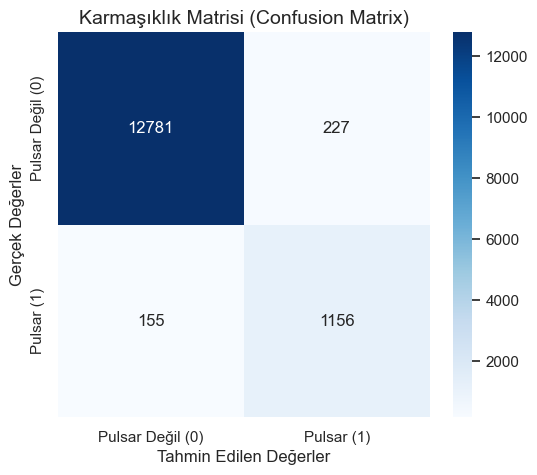

In [35]:
# Karmaşıklık Matrisi Görselleştirmesi
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pulsar Değil (0)', 'Pulsar (1)'], 
            yticklabels=['Pulsar Değil (0)', 'Pulsar (1)'])
plt.title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=14)
plt.ylabel('Gerçek Değerler', fontsize=12)
plt.xlabel('Tahmin Edilen Değerler', fontsize=12)
plt.show()